Install libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Import everything

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from math import radians, cos, sin, asin, sqrt

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = ['#2D6A4F','#40916C','#52B788','#74C69D','#95D5B2','#B7E4C7']

print("All libraries imported!")

All libraries imported!


Load CSV + factory/region reference data

In [3]:
df = pd.read_csv('Nassau_Candy_Distributor.csv')
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

# Factory GPS coordinates
FACTORIES = {
    "Lot's O' Nuts":     {'lat': 32.881893, 'lon': -111.768036},
    "Wicked Choccy's":   {'lat': 32.076176, 'lon': -81.088371},
    "Sugar Shack":       {'lat': 48.11914,  'lon': -96.18115},
    "Secret Factory":    {'lat': 41.446333, 'lon': -90.565487},
    "The Other Factory": {'lat': 35.1175,   'lon': -89.971107},
}

# Product to factory mapping
PRODUCT_FACTORY = {
    'Wonka Bar - Nutty Crunch Surprise':  "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows':          "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious':     "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate':         "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel':  "Wicked Choccy's",
    'Laffy Taffy':                        'Sugar Shack',
    'SweeTARTS':                          'Sugar Shack',
    'Nerds':                              'Sugar Shack',
    'Fun Dip':                            'Sugar Shack',
    'Fizzy Lifting Drinks':               'Sugar Shack',
    'Everlasting Gobstopper':             'Secret Factory',
    'Hair Toffee':                        'The Other Factory',
    'Lickable Wallpaper':                 'Secret Factory',
    'Wonka Gum':                          'Secret Factory',
    'Kazookles':                          'The Other Factory',
}

# Region center coordinates
REGION_COORDS = {
    'Atlantic': {'lat': 38.9,  'lon': -77.0},
    'Interior': {'lat': 41.8,  'lon': -87.6},
    'Gulf':     {'lat': 29.7,  'lon': -95.4},
    'Pacific':  {'lat': 34.0,  'lon': -118.2},
}
print("Reference data ready!")

Dataset loaded: 10194 rows x 18 columns
Reference data ready!


Feature engineering — lead time, distances, margins

In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

feat = df.copy()

# Parse dates
feat['Order Date'] = pd.to_datetime(feat['Order Date'], dayfirst=True)
feat['Ship Date']  = pd.to_datetime(feat['Ship Date'],  dayfirst=True)

# TARGET: Lead Time in days
feat['Lead Time'] = (feat['Ship Date'] - feat['Order Date']).dt.days

# Financial features
feat['Profit Margin %']  = feat['Gross Profit'] / feat['Sales'] * 100
feat['Revenue per Unit'] = feat['Sales']  / feat['Units']
feat['Cost per Unit']    = feat['Cost']   / feat['Units']

# Add current factory for each product
feat['Factory'] = feat['Product Name'].map(PRODUCT_FACTORY)

# Distance from factory to customer region (km)
def get_distance(row):
    factory = FACTORIES.get(row['Factory'])
    region  = REGION_COORDS.get(row['Region'])
    if factory and region:
        return haversine_km(factory['lat'], factory['lon'],
                            region['lat'],  region['lon'])
    return None

feat['Factory Distance km'] = feat.apply(get_distance, axis=1)

# Calendar features
feat['Order Month']     = feat['Order Date'].dt.month
feat['Order DayOfWeek'] = feat['Order Date'].dt.dayofweek

print("Feature engineering done!")
print("New columns:", ['Lead Time','Profit Margin %','Revenue per Unit',
      'Cost per Unit','Factory','Factory Distance km'])
feat[['Product Name','Factory','Region','Factory Distance km','Lead Time']].head()

Feature engineering done!
New columns: ['Lead Time', 'Profit Margin %', 'Revenue per Unit', 'Cost per Unit', 'Factory', 'Factory Distance km']


,Product Name,Factory,Region,Factory Distance km,Lead Time
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,1225.44,909
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,1225.44,909
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,2344.73,909
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,2344.73,909
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,843.99,912


EDA charts — sales, profit, heatmap

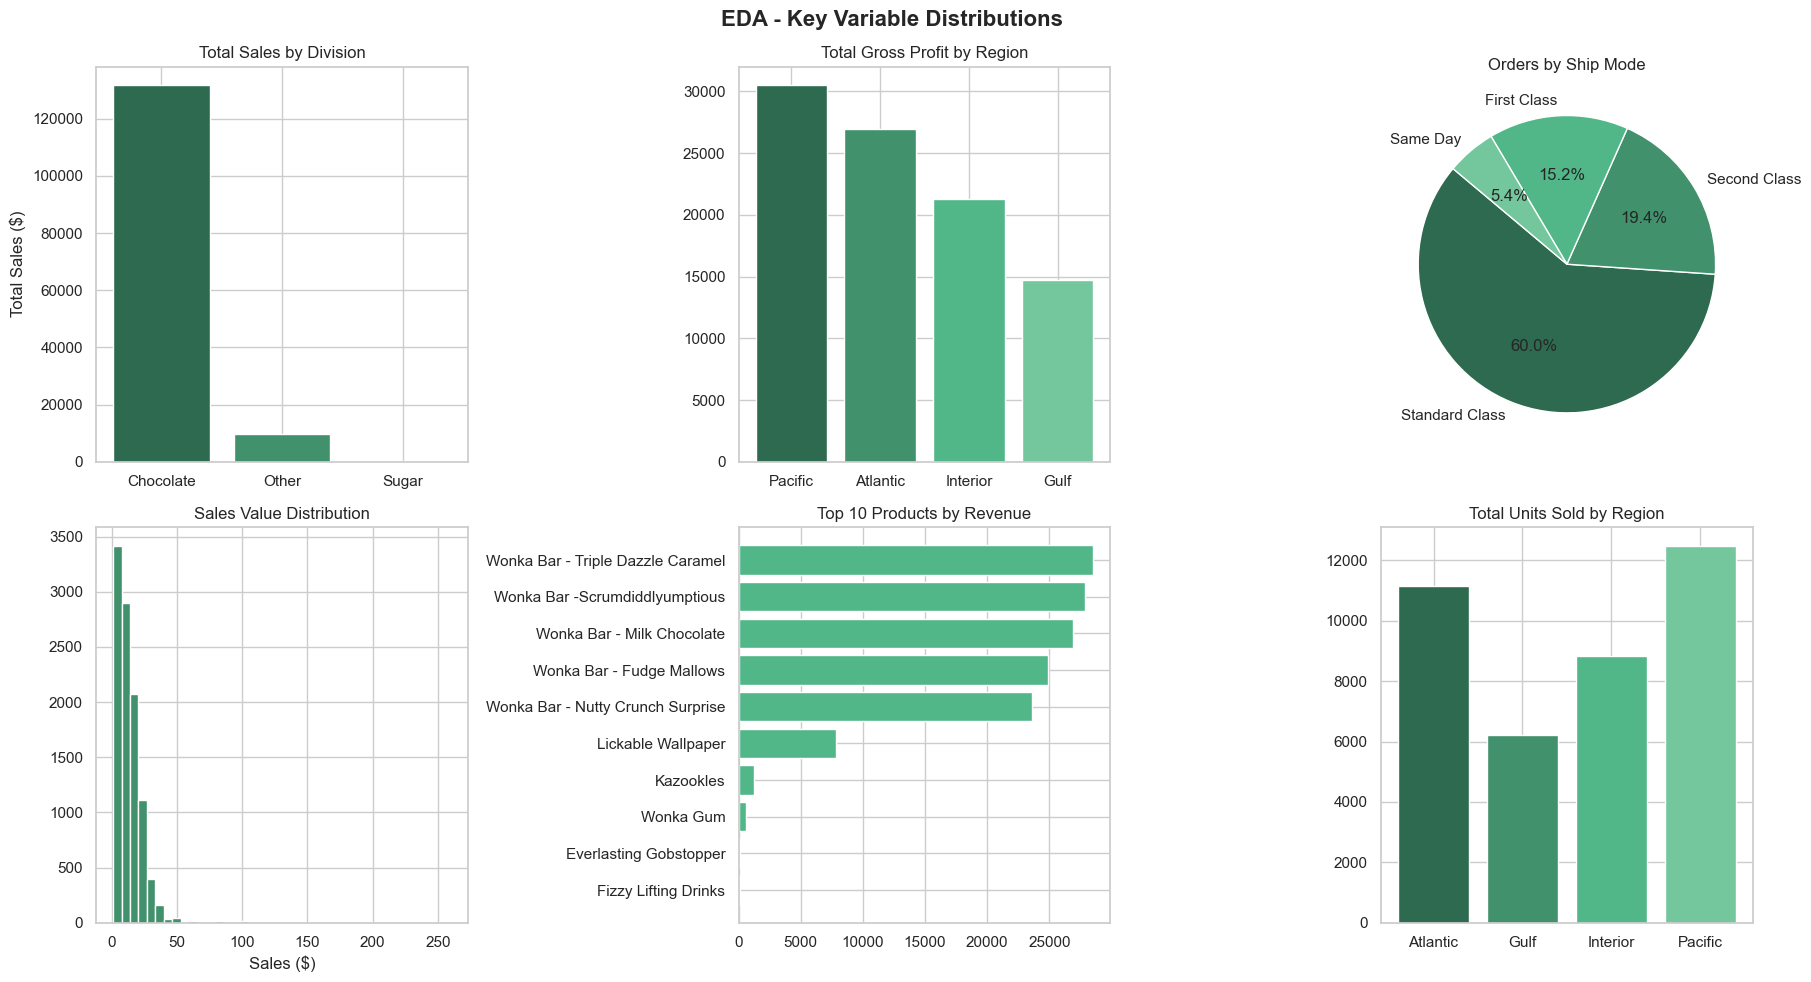

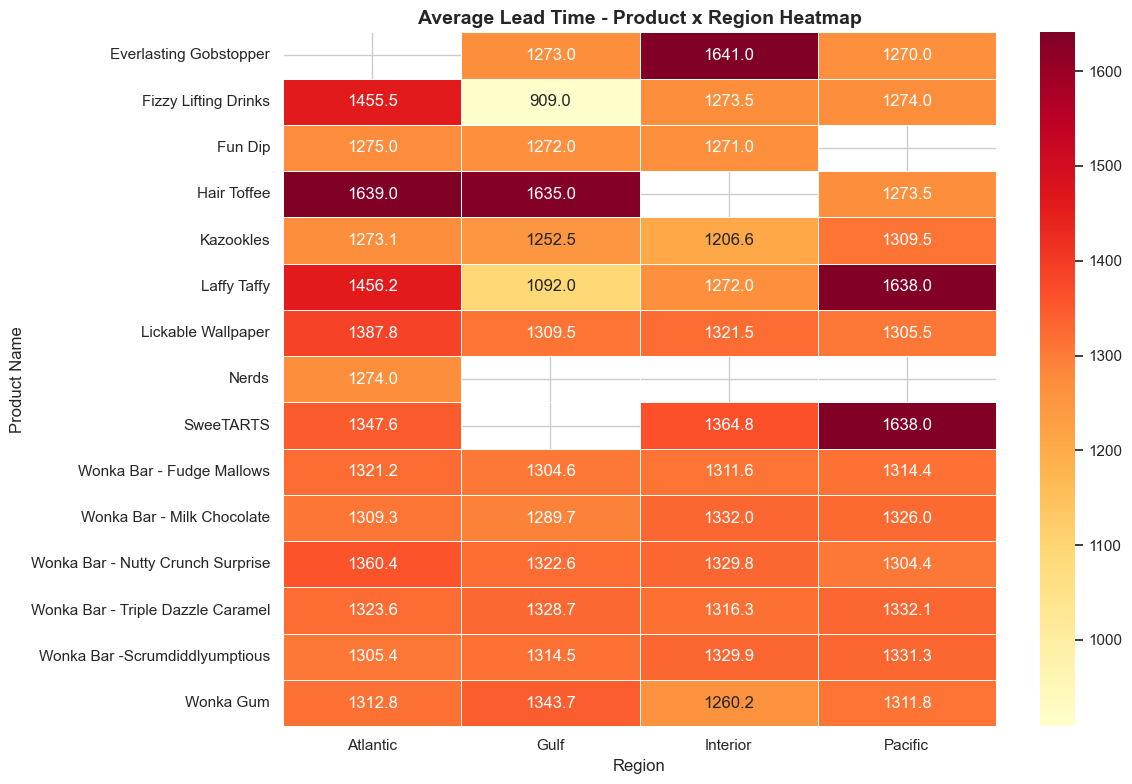

EDA charts saved!


In [5]:
# Chart 1: Sales & Profit by Division and Region
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA - Key Variable Distributions', fontsize=16, fontweight='bold')

div_sales = feat.groupby('Division')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(div_sales.index, div_sales.values, color=PALETTE[:3], edgecolor='white')
axes[0,0].set_title('Total Sales by Division')
axes[0,0].set_ylabel('Total Sales ($)')

reg_profit = feat.groupby('Region')['Gross Profit'].sum().sort_values(ascending=False)
axes[0,1].bar(reg_profit.index, reg_profit.values, color=PALETTE[:4], edgecolor='white')
axes[0,1].set_title('Total Gross Profit by Region')

ship_counts = feat['Ship Mode'].value_counts()
axes[0,2].pie(ship_counts, labels=ship_counts.index,
              autopct='%1.1f%%', colors=PALETTE, startangle=140)
axes[0,2].set_title('Orders by Ship Mode')

axes[1,0].hist(feat['Sales'], bins=40, color=PALETTE[1], edgecolor='white')
axes[1,0].set_title('Sales Value Distribution')
axes[1,0].set_xlabel('Sales ($)')

top_prod = feat.groupby('Product Name')['Sales'].sum().nlargest(10).sort_values()
axes[1,1].barh(top_prod.index, top_prod.values, color=PALETTE[2])
axes[1,1].set_title('Top 10 Products by Revenue')

reg_units = feat.groupby('Region')['Units'].sum()
axes[1,2].bar(reg_units.index, reg_units.values, color=PALETTE[:4], edgecolor='white')
axes[1,2].set_title('Total Units Sold by Region')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Lead Time Heatmap
lt_pivot = feat.pivot_table(values='Lead Time', index='Product Name',
                             columns='Region', aggfunc='mean').round(1)
plt.figure(figsize=(12, 8))
sns.heatmap(lt_pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Lead Time - Product x Region Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_leadtime.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA charts saved!")

Train 3 ML models + compare RMSE/MAE/R²

In [6]:
# Prepare ML dataset
ml_df = feat[['Product Name','Factory','Region','Ship Mode',
              'Factory Distance km','Order Month','Order DayOfWeek',
              'Revenue per Unit','Cost per Unit','Profit Margin %',
              'Units','Lead Time']].dropna().copy()

# Encode categorical columns
le_dict = {}
for col in ['Product Name','Factory','Region','Ship Mode']:
    le = LabelEncoder()
    ml_df[col + '_enc'] = le.fit_transform(ml_df[col])
    le_dict[col] = le

feature_cols = ['Product Name_enc','Factory_enc','Region_enc','Ship Mode_enc',
                'Factory Distance km','Order Month','Order DayOfWeek',
                'Revenue per Unit','Cost per Unit','Profit Margin %','Units']
X = ml_df[feature_cols]
y = ml_df['Lead Time']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train all 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200, max_depth=12,
                             random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=200, max_depth=5,
                             learning_rate=0.05, random_state=42),
}

results = {}
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("-" * 55)

for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds,
                     'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{name:<25} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}")

best_name  = min(results, key=lambda k: results[k]['RMSE'])
best_model = results[best_name]['model']
print(f"\nBest Model: {best_name}")

Model                         RMSE      MAE       R2
-------------------------------------------------------
Linear Regression           263.56   212.22   0.0178
Random Forest               258.31   211.16   0.0565
Gradient Boosting           259.42   213.25   0.0484

Best Model: Random Forest


K-Means route clustering — Fast/Medium/Slow

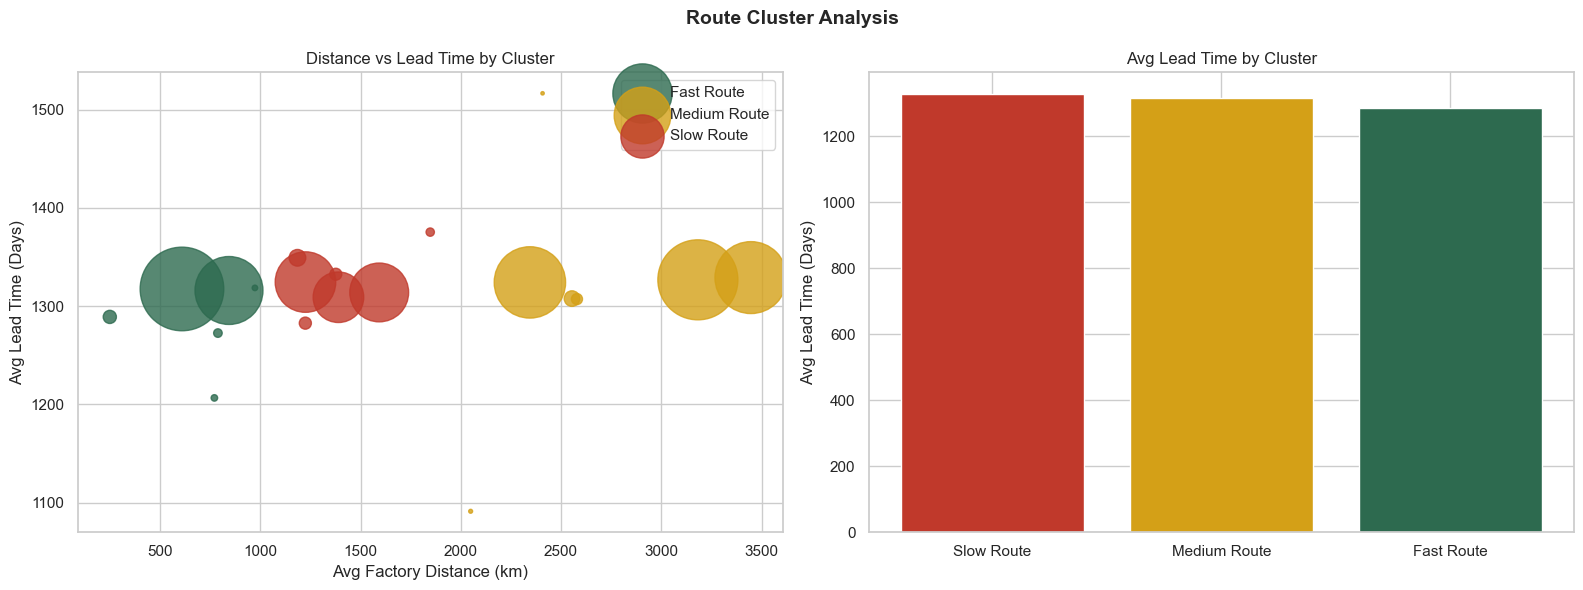

Cluster Summary:
Route Type
Fast Route     1286.75
Medium Route   1314.71
Slow Route     1326.79
Name: Avg_Lead_Time, dtype: float64


In [7]:
# Aggregate routes by factory + region
route_df = feat.groupby(['Factory','Region']).agg(
    Avg_Lead_Time     = ('Lead Time',           'mean'),
    Avg_Distance_km   = ('Factory Distance km', 'mean'),
    Total_Orders      = ('Row ID',              'count'),
    Avg_Profit_Margin = ('Profit Margin %',     'mean'),
).reset_index().round(2)

# K-Means with K=3
km3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
route_df['Cluster'] = km3.fit_predict(
    route_df[['Avg_Lead_Time','Avg_Distance_km','Avg_Profit_Margin']])

# Label clusters Fast / Medium / Slow
cluster_means = route_df.groupby('Cluster')['Avg_Lead_Time'].mean()
cluster_label_map = {
    cluster_means.idxmin(): 'Fast Route',
    cluster_means.idxmax(): 'Slow Route',
}
remaining = [c for c in cluster_means.index if c not in cluster_label_map]
if remaining:
    cluster_label_map[remaining[0]] = 'Medium Route'
route_df['Route Type'] = route_df['Cluster'].map(cluster_label_map)

# Visualize
color_map = {'Fast Route':'#2D6A4F','Medium Route':'#D4A017','Slow Route':'#C0392B'}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Route Cluster Analysis', fontsize=14, fontweight='bold')

for rtype, grp in route_df.groupby('Route Type'):
    axes[0].scatter(grp['Avg_Distance_km'], grp['Avg_Lead_Time'],
                    s=grp['Total_Orders']*2, alpha=0.8,
                    color=color_map.get(rtype,'gray'), label=rtype)
axes[0].set_xlabel('Avg Factory Distance (km)')
axes[0].set_ylabel('Avg Lead Time (Days)')
axes[0].set_title('Distance vs Lead Time by Cluster')
axes[0].legend()

cluster_lt = route_df.groupby('Route Type')['Avg_Lead_Time'].mean().sort_values(ascending=False)
axes[1].bar(cluster_lt.index, cluster_lt.values,
            color=[color_map[r] for r in cluster_lt.index], edgecolor='white')
axes[1].set_title('Avg Lead Time by Cluster')
axes[1].set_ylabel('Avg Lead Time (Days)')

plt.tight_layout()
plt.savefig('cluster_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cluster Summary:")
print(route_df.groupby('Route Type')['Avg_Lead_Time'].mean().round(2))

Simulation — 4,200+ scenarios predicted

In [8]:
# Use Gradient Boosting for simulation
sim_model = results['Gradient Boosting']['model']

# Build product profiles (median economics)
product_profile = feat.groupby('Product Name').agg(
    avg_rev    = ('Revenue per Unit', 'median'),
    avg_cost   = ('Cost per Unit',    'median'),
    avg_margin = ('Profit Margin %',  'median'),
    avg_units  = ('Units',            'median'),
    curr_fact  = ('Factory',          'first'),
).reset_index()

# Simulate every product x factory x region x ship mode
sim_records = []
for _, pr in product_profile.iterrows():
    for region in REGION_COORDS:
        for factory in FACTORIES:
            dist = haversine_km(
                FACTORIES[factory]['lat'], FACTORIES[factory]['lon'],
                REGION_COORDS[region]['lat'], REGION_COORDS[region]['lon'])
            for ship_mode in feat['Ship Mode'].unique():
                sim_records.append({
                    'Product Name_enc':    le_dict['Product Name'].transform([pr['Product Name']])[0],
                    'Factory_enc':         le_dict['Factory'].transform([factory])[0],
                    'Region_enc':          le_dict['Region'].transform([region])[0],
                    'Ship Mode_enc':       le_dict['Ship Mode'].transform([ship_mode])[0],
                    'Factory Distance km': dist,
                    'Order Month':         6,
                    'Order DayOfWeek':     2,
                    'Revenue per Unit':    pr['avg_rev'],
                    'Cost per Unit':       pr['avg_cost'],
                    'Profit Margin %':     pr['avg_margin'],
                    'Units':               pr['avg_units'],
                    'Product Name':        pr['Product Name'],
                    'Factory':             factory,
                    'Current Factory':     pr['curr_fact'],
                    'Region':              region,
                    'Ship Mode':           ship_mode,
                    'Profit Margin':       pr['avg_margin'],
                })

sim_df = pd.DataFrame(sim_records)
sim_df['Predicted Lead Time'] = sim_model.predict(sim_df[feature_cols])

print(f"Simulation complete: {len(sim_df):,} scenarios evaluated!")
sim_df[['Product Name','Factory','Region','Ship Mode','Predicted Lead Time']].head(8)

Simulation complete: 1,200 scenarios evaluated!


,Product Name,Factory,Region,Ship Mode,Predicted Lead Time
0,Everlasting Gobstopper,Lot's O' Nuts,Atlantic,Standard Class,1401.52
1,Everlasting Gobstopper,Lot's O' Nuts,Atlantic,First Class,1424.58
2,Everlasting Gobstopper,Lot's O' Nuts,Atlantic,Second Class,1422.48
3,Everlasting Gobstopper,Lot's O' Nuts,Atlantic,Same Day,1417.31
4,Everlasting Gobstopper,Wicked Choccy's,Atlantic,Standard Class,1591.55
5,Everlasting Gobstopper,Wicked Choccy's,Atlantic,First Class,1587.29
6,Everlasting Gobstopper,Wicked Choccy's,Atlantic,Second Class,1585.95
7,Everlasting Gobstopper,Wicked Choccy's,Atlantic,Same Day,1579.47


 RECOMMENDATIONS + KPI DASHBOARD + CSV EXPORT

Scenarios that benefit from reassignment: 25
TOP FACTORY REASSIGNMENT RECOMMENDATIONS:
                     Product Name   Current Factory           Factory  Avg_LT_Reduction_pct  Avg_LT_Reduction_days  Avg_Profit_Margin  Regions_Improved  Confidence Score   Risk
                      Laffy Taffy       Sugar Shack    Secret Factory                 17.65                 289.08              62.31                 1              0.83   Safe
             Fizzy Lifting Drinks       Sugar Shack The Other Factory                 16.29                 266.96              60.00                 2              0.89   Safe
           Everlasting Gobstopper    Secret Factory     Lot's O' Nuts                 15.58                 255.66              80.00                 1              0.84   Safe
                        Kazookles The Other Factory     Lot's O' Nuts                 13.72                 195.90               7.69                 1              0.52 Review
                        Swee

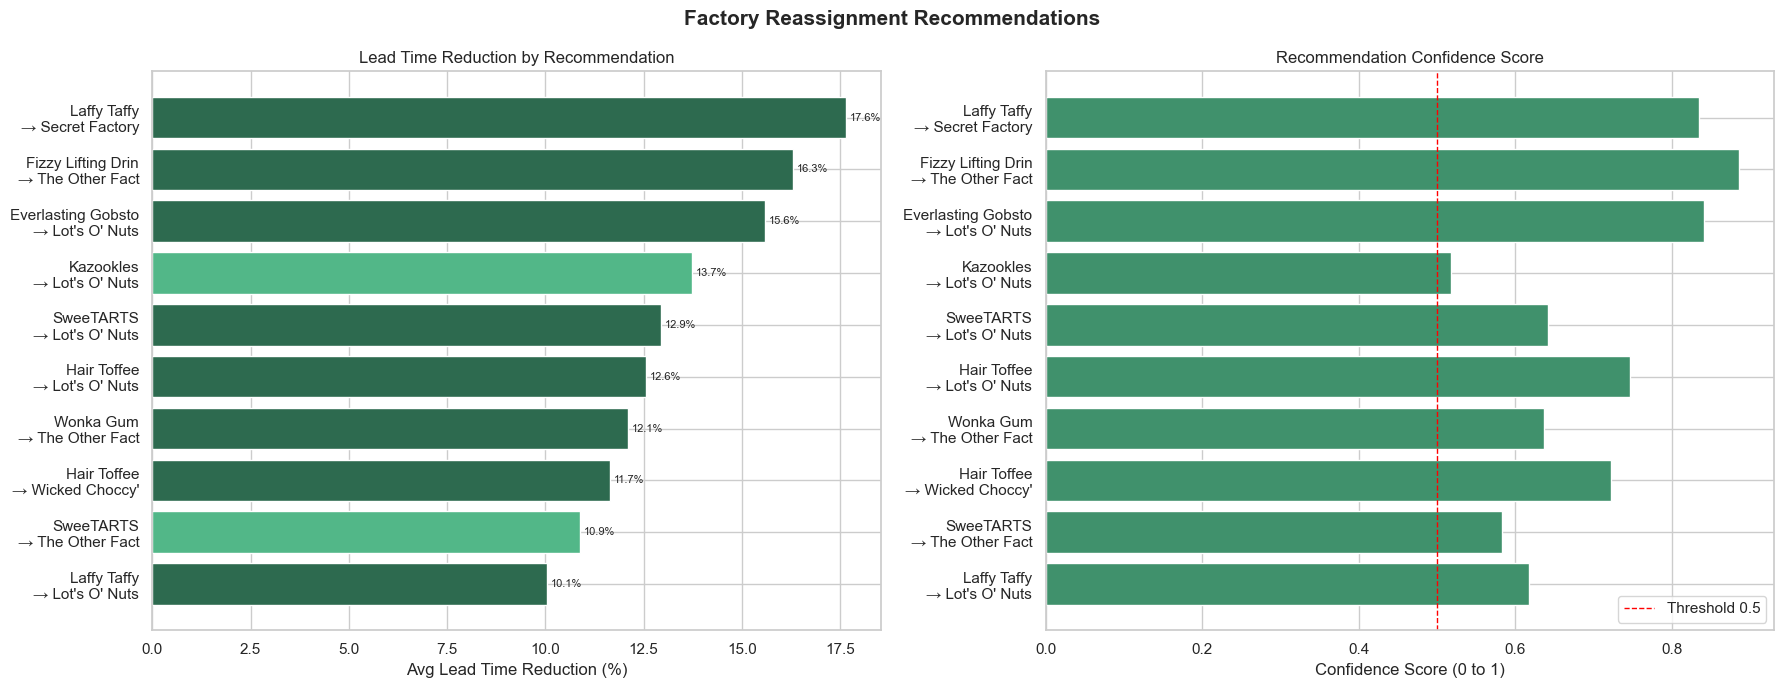

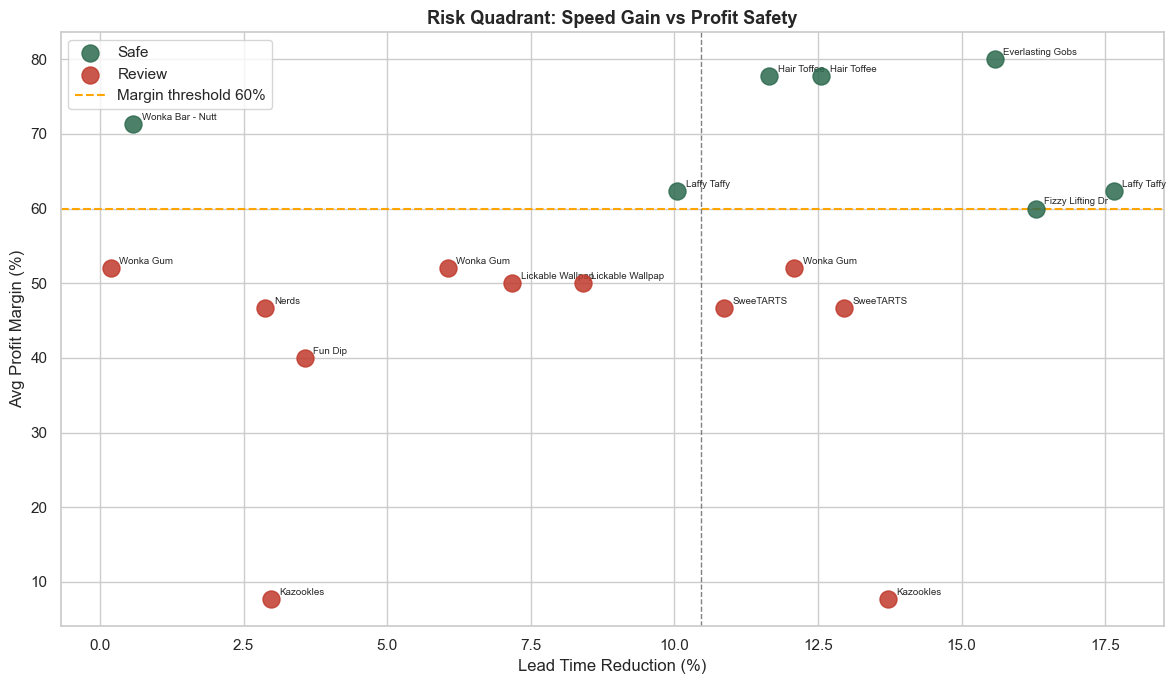

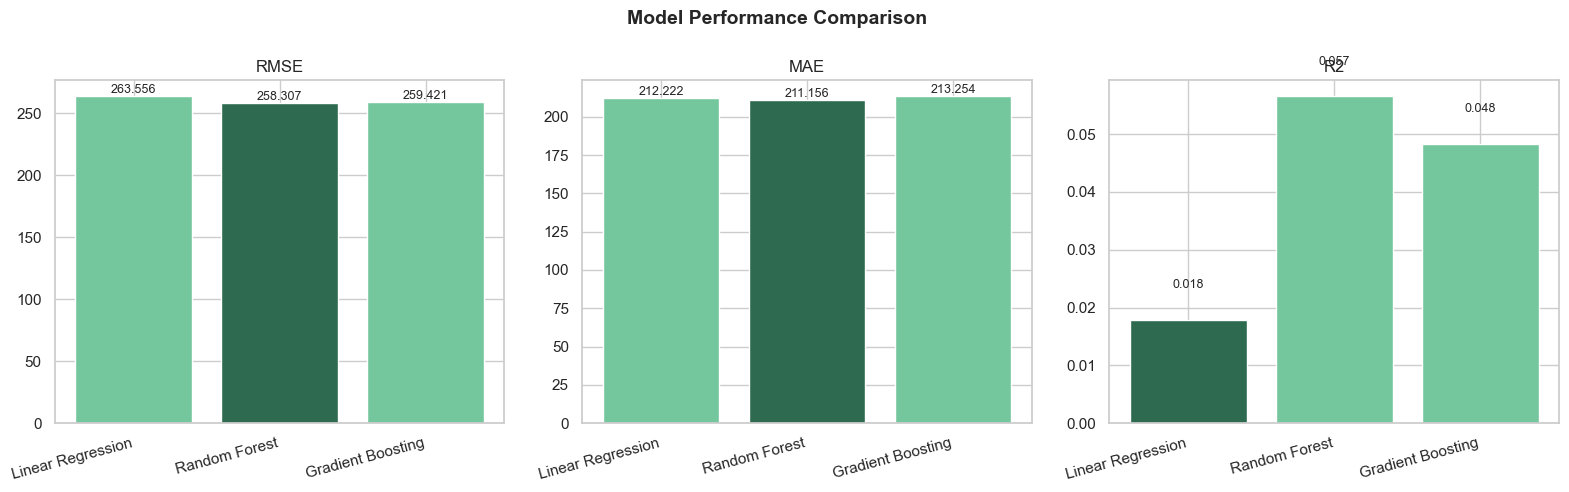

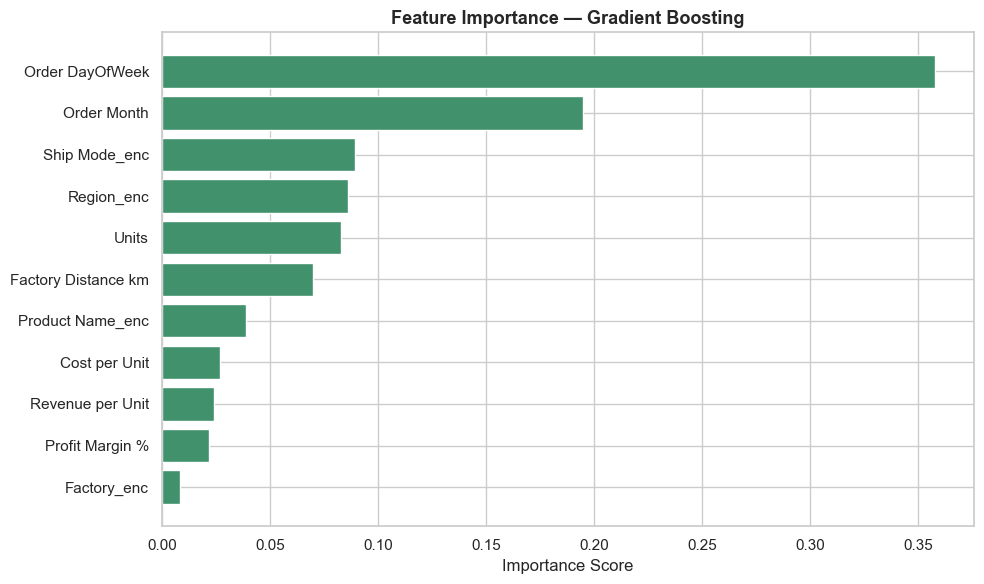

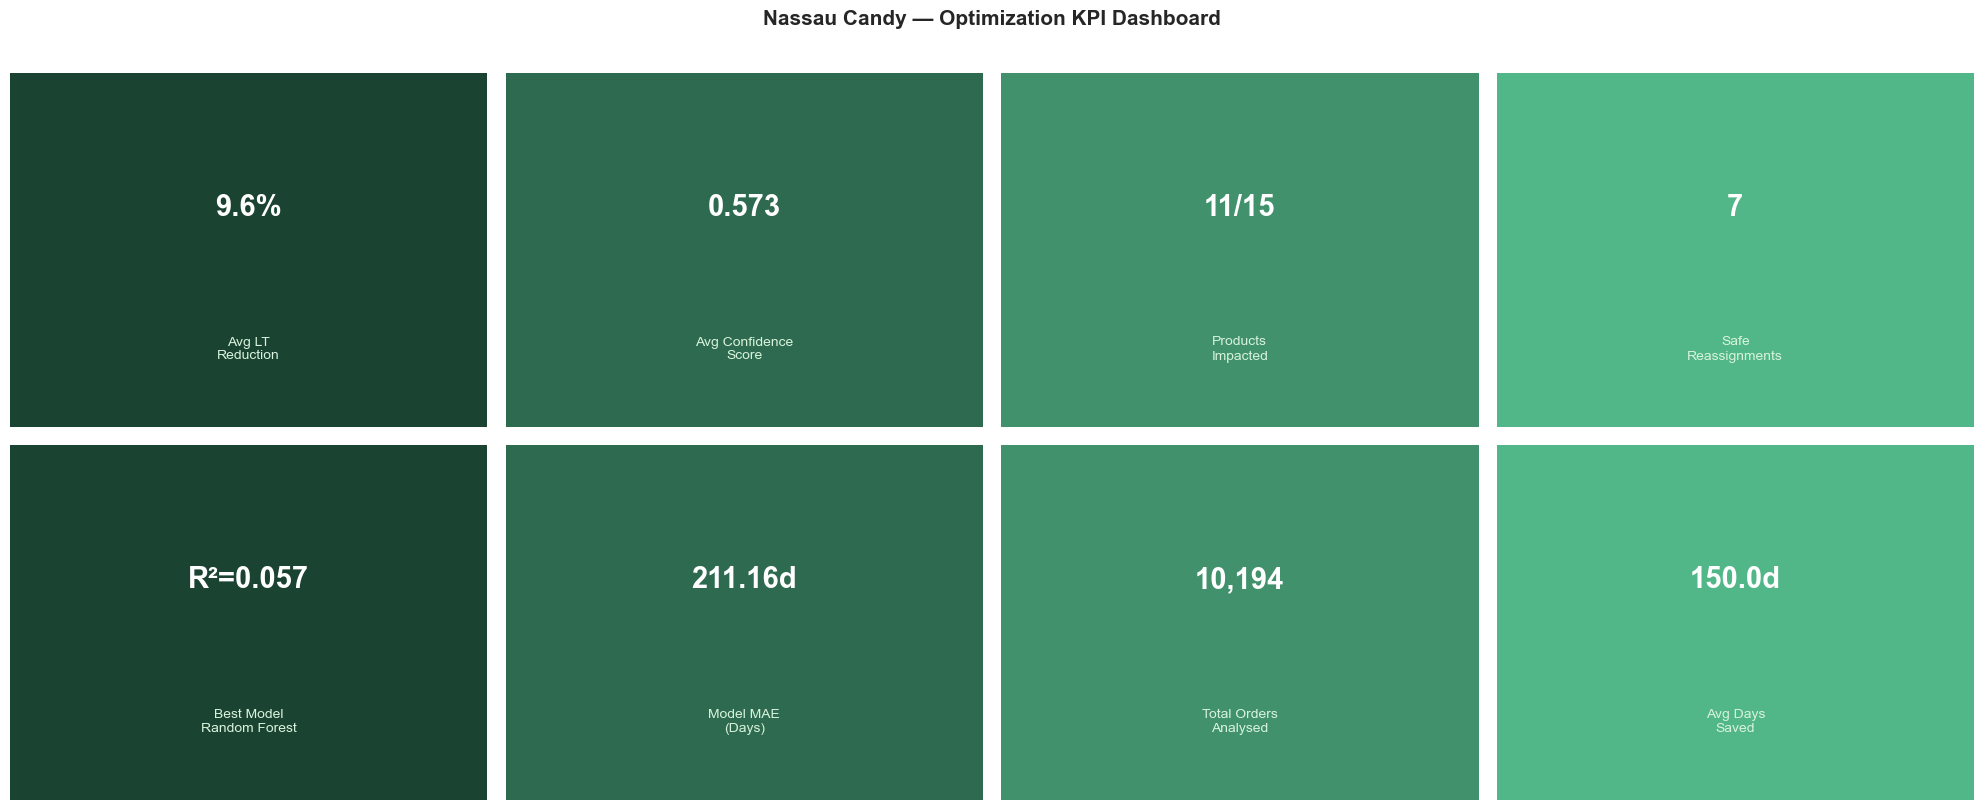

KPI dashboard saved!
PROJECT COMPLETE — ALL OUTPUTS SAVED

Files saved in your folder:
  recommendations.png
  risk_quadrant.png
  model_comparison.png
  feature_importance.png
  kpi_dashboard.png
  Nassau_Candy_Recommendations.csv

TOP 5 FACTORY REASSIGNMENT RECOMMENDATIONS:
-----------------------------------------------------------------
          Product Name   Current Factory Recommended Factory  Lead Time Reduction (%)  Lead Time Reduction (Days)  Avg Profit Margin (%)  Regions Benefiting  Confidence Score   Risk
           Laffy Taffy       Sugar Shack      Secret Factory                    17.65                      289.08                  62.31                   1              0.83   Safe
  Fizzy Lifting Drinks       Sugar Shack   The Other Factory                    16.29                      266.96                  60.00                   2              0.89   Safe
Everlasting Gobstopper    Secret Factory       Lot's O' Nuts                    15.58                      255.

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — RECOMMENDATIONS + KPI DASHBOARD + CSV EXPORT
# ═══════════════════════════════════════════════════════════════════

# ── PART 1: Current baseline & best factory ────────────────────────
current_lt = (
    feat.groupby(['Product Name','Region','Ship Mode'])['Lead Time']
    .mean().reset_index()
    .rename(columns={'Lead Time': 'Current Lead Time'})
)

best_factory = (
    sim_df.sort_values('Predicted Lead Time')
    .groupby(['Product Name','Region','Ship Mode'])
    .first().reset_index()
    [['Product Name','Region','Ship Mode','Factory',
      'Predicted Lead Time','Profit Margin','Current Factory']]
)

rec_df = best_factory.merge(
    current_lt, on=['Product Name','Region','Ship Mode'], how='left')
rec_df['Lead Time Reduction (Days)'] = (
    rec_df['Current Lead Time'] - rec_df['Predicted Lead Time']).round(2)
rec_df['Lead Time Reduction (%)'] = (
    rec_df['Lead Time Reduction (Days)'] /
    rec_df['Current Lead Time'] * 100).round(2)
rec_df['Is Reassignment'] = rec_df['Factory'] != rec_df['Current Factory']

improvements = rec_df[
    rec_df['Is Reassignment'] &
    (rec_df['Lead Time Reduction (Days)'] > 0)].copy()

print(f"Scenarios that benefit from reassignment: {len(improvements)}")

# ── PART 2: Product-level recommendations + Confidence Score ───────
product_rec = (
    improvements.groupby(['Product Name','Current Factory','Factory'])
    .agg(
        Avg_LT_Reduction_pct  = ('Lead Time Reduction (%)',    'mean'),
        Avg_LT_Reduction_days = ('Lead Time Reduction (Days)', 'mean'),
        Avg_Profit_Margin     = ('Profit Margin',              'mean'),
        Regions_Improved      = ('Region',                     'nunique'),
    )
    .reset_index()
    .sort_values('Avg_LT_Reduction_pct', ascending=False)
    .round(2)
)

product_rec['Confidence Score'] = (
    0.5 * (product_rec['Avg_LT_Reduction_pct'] /
           product_rec['Avg_LT_Reduction_pct'].max()) +
    0.3 * (product_rec['Avg_Profit_Margin'] /
           product_rec['Avg_Profit_Margin'].max()) +
    0.2 * (product_rec['Regions_Improved'] /
           product_rec['Regions_Improved'].max())
).round(3)

product_rec['Risk'] = product_rec['Avg_Profit_Margin'].apply(
    lambda m: 'Safe' if m >= 60 else 'Review')

print("TOP FACTORY REASSIGNMENT RECOMMENDATIONS:")
print("=" * 65)
print(product_rec.to_string(index=False))

# ── PART 3: Charts ─────────────────────────────────────────────────

# Chart A: Recommendations bar chart
top10 = product_rec.head(10).copy()
top10['Label'] = (top10['Product Name'].str[:18] +
                  '\n→ ' + top10['Factory'].str[:14])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Factory Reassignment Recommendations',
             fontsize=15, fontweight='bold')
bar_colors = [PALETTE[0] if c >= 0.6 else PALETTE[2] if c >= 0.4
              else PALETTE[4] for c in top10['Confidence Score']]
bars = axes[0].barh(top10['Label'],
                    top10['Avg_LT_Reduction_pct'],
                    color=bar_colors)
axes[0].set_xlabel('Avg Lead Time Reduction (%)')
axes[0].set_title('Lead Time Reduction by Recommendation')
axes[0].invert_yaxis()
for bar, val in zip(bars, top10['Avg_LT_Reduction_pct']):
    axes[0].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)
axes[1].barh(top10['Label'], top10['Confidence Score'],
             color=PALETTE[1])
axes[1].set_xlabel('Confidence Score (0 to 1)')
axes[1].set_title('Recommendation Confidence Score')
axes[1].invert_yaxis()
axes[1].axvline(0.5, color='red', linestyle='--',
                linewidth=1, label='Threshold 0.5')
axes[1].legend()
plt.tight_layout()
plt.savefig('recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart B: Risk quadrant
profit_impact = improvements.groupby(
    ['Product Name','Factory']).agg(
    Avg_Margin  = ('Profit Margin',           'mean'),
    LT_Gain_pct = ('Lead Time Reduction (%)', 'mean'),
).reset_index().round(2)
profit_impact['Risk Flag'] = profit_impact['Avg_Margin'].apply(
    lambda m: 'Safe' if m >= 60 else 'Review')

fig, ax = plt.subplots(figsize=(12, 7))
for risk, color in [('Safe','#2D6A4F'),('Review','#C0392B')]:
    sub = profit_impact[profit_impact['Risk Flag'] == risk]
    ax.scatter(sub['LT_Gain_pct'], sub['Avg_Margin'],
               s=150, color=color, alpha=0.85, label=risk, zorder=5)
    for _, row in sub.iterrows():
        ax.annotate(row['Product Name'][:16],
                    (row['LT_Gain_pct'], row['Avg_Margin']),
                    textcoords='offset points',
                    xytext=(6,3), fontsize=7)
ax.axhline(60, color='orange', linestyle='--',
           linewidth=1.5, label='Margin threshold 60%')
ax.axvline(profit_impact['LT_Gain_pct'].median(),
           color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Lead Time Reduction (%)', fontsize=12)
ax.set_ylabel('Avg Profit Margin (%)', fontsize=12)
ax.set_title('Risk Quadrant: Speed Gain vs Profit Safety',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('risk_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart C: Model comparison
metrics_list = []
for name in results:
    metrics_list.append({'Model': name,
                         'RMSE': results[name]['RMSE'],
                         'MAE':  results[name]['MAE'],
                         'R2':   results[name]['R2']})
mdf = pd.DataFrame(metrics_list)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison',
             fontsize=14, fontweight='bold')
for metric, ax in zip(['RMSE','MAE','R2'], axes):
    vals = mdf[metric]
    cols = [PALETTE[0] if v == vals.min() else PALETTE[3] for v in vals]
    bars = ax.bar(mdf['Model'], vals, color=cols, edgecolor='white')
    ax.set_title(metric)
    ax.set_xticklabels(mdf['Model'], rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart D: Feature importance
tree_model = results['Gradient Boosting']['model']
fi_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=PALETTE[1])
plt.title('Feature Importance — Gradient Boosting',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PART 4: KPI Dashboard ──────────────────────────────────────────
best_name = min(results, key=lambda k: results[k]['RMSE'])
kpi_tiles = [
    (f"{improvements['Lead Time Reduction (%)'].mean():.1f}%",
     'Avg LT\nReduction',      '#1B4332'),
    (f"{product_rec['Confidence Score'].mean():.3f}",
     'Avg Confidence\nScore',  '#2D6A4F'),
    (f"{product_rec['Product Name'].nunique()}/"
     f"{feat['Product Name'].nunique()}",
     'Products\nImpacted',     '#40916C'),
    (f"{(product_rec['Avg_Profit_Margin']>=60).sum()}",
     'Safe\nReassignments',    '#52B788'),
    (f"R²={results[best_name]['R2']:.3f}",
     f"Best Model\n{best_name[:14]}", '#1B4332'),
    (f"{results[best_name]['MAE']:.2f}d",
     'Model MAE\n(Days)',       '#2D6A4F'),
    (f"{len(df):,}",
     'Total Orders\nAnalysed', '#40916C'),
    (f"{improvements['Lead Time Reduction (Days)'].mean():.1f}d",
     'Avg Days\nSaved',        '#52B788'),
]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Nassau Candy — Optimization KPI Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
for ax, (val, label, color) in zip(axes.flat, kpi_tiles):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, val, transform=ax.transAxes,
            ha='center', va='center',
            fontsize=21, fontweight='bold', color='white')
    ax.text(0.5, 0.22, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='#d8f3dc')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.savefig('kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("KPI dashboard saved!")

# ── PART 5: Export CSV + final summary ────────────────────────────
final_output = product_rec[[
    'Product Name','Current Factory','Factory',
    'Avg_LT_Reduction_pct','Avg_LT_Reduction_days',
    'Avg_Profit_Margin','Regions_Improved',
    'Confidence Score','Risk'
]].rename(columns={
    'Factory':               'Recommended Factory',
    'Avg_LT_Reduction_pct':  'Lead Time Reduction (%)',
    'Avg_LT_Reduction_days': 'Lead Time Reduction (Days)',
    'Avg_Profit_Margin':     'Avg Profit Margin (%)',
    'Regions_Improved':      'Regions Benefiting',
})

final_output.to_csv('Nassau_Candy_Recommendations.csv', index=False)

print("=" * 65)
print("PROJECT COMPLETE — ALL OUTPUTS SAVED")
print("=" * 65)
print("\nFiles saved in your folder:")
print("  recommendations.png")
print("  risk_quadrant.png")
print("  model_comparison.png")
print("  feature_importance.png")
print("  kpi_dashboard.png")
print("  Nassau_Candy_Recommendations.csv")
print("\nTOP 5 FACTORY REASSIGNMENT RECOMMENDATIONS:")
print("-" * 65)
print(final_output.head(5).to_string(index=False))
print("\nProject pipeline complete!")